
<h1 id="1.1-%E7%94%A8TTree-%E7%BB%93%E6%9E%84%E5%AD%98%E5%82%A8%E4%BA%8B%E4%BB%B6%E6%95%B0%E6%8D%AE">1.1 用TTree 结构存储事件数据</h1><h3 id="1.-%E7%9B%AE%E7%9A%84">1. 目的</h3><ul>
<li>理解核物理实验中“事件（Event）”的概念。</li>
<li>掌握如何利用 Monte Carlo 方法模拟粒子探测过程。</li>
<li>学习将数据以 TTree 格式存储到 ROOT 文件中。</li>
</ul>
<h3 id="2%E3%80%81-%E5%AE%9E%E9%AA%8C%E8%AE%BE%E7%BD%AE%E4%B8%8E%E7%89%A9%E7%90%86%E5%8E%9F%E7%90%86">2、 实验设置与物理原理</h3><p>束流入射到靶上产生核反应，生成中子和$\gamma$ flash。这些次级粒子飞行一段距离后，击中一个长条型塑料闪烁体探测器。</p>
<h4 id="2.1.-%E5%87%A0%E4%BD%95%E8%AE%BE%E7%BD%AE">2.1. 几何设置</h4><ul>
<li>束流：沿 $y$ 轴射入，打在靶点 ($0,0$) 上。<ul>
<li>探测器：长条形塑料闪烁体。</li>
<li>位置：中心位于 $(0, D)$，即距靶点垂直距离为 $D$。</li>
<li>尺寸：长 $2L$，厚度 $T$（忽略宽度）。</li>
<li>坐标系：探测器沿 $X$ 轴放置。粒子击中位置 $x \in [-L, L]$。</li>
<li>粒子可能在探测器厚度范围内任意深度 $y' \in [-T/2, T/2]$ 发生反应。</li>
</ul>
</li>
</ul>
<img alt="Image" height="50%" src="fig/tof.png" width="50%"/>
<h4 id="2.2.-%E4%BF%A1%E5%8F%B7%E8%AF%BB%E5%87%BA">2.2. 信号读出</h4><p>探测器两端分别用光电倍增管（PMT）读出信号，定义为 Left (图中u) 和 Right (图中d) 端。</p>
<ul>
<li><strong>Time</strong>：记录信号到达时间 ($t_L, t_R$)。</li>
<li><strong>Charge</strong>：记录沉积能量 ($q_L, q_R$)。</li>
</ul>
<h4 id="2.3.-%E7%89%A9%E7%90%86%E5%85%AC%E5%BC%8F">2.3. 物理公式</h4><p><strong>A. 飞行时间 (TOF)</strong></p>
<p>粒子从靶点飞到反应点 $(x,D+y')$ 的真实距离：
$$ d = \sqrt{x^2 + (D+y')^2} $$</p>
<ul>
<li><strong>Gamma ($\gamma$)</strong>：以光速 $c$ 飞行。
$$ \text{TOF}_\gamma [\text{ns}]\approx 3.33* d(\text{m}) $$</li>
<li><strong>中子 ($n$)</strong>：非相对论近似，能量 $E_n$ (MeV)。
$$ \text{TOF}_n [\text{ns}] \approx 72.3 \times \frac{d [\text{m}]}{\sqrt{E_n [\text{MeV}]}} $$</li>
</ul>
<p><strong>B. 探测器时间响应</strong></p>
<p>光在闪烁体中传输速度为 $v_{sc}$。</p>
<p>$$ t^{(0)}_L = \text{TOF} + \frac{L+x}{v_{sc}} + t_{0L} $$
$$ t^{(0)}_R = \text{TOF} + \frac{L-x}{v_{sc}} + t_{0R}$$</p>
<p>其中 $t_{0L}$,$t_{0R}$：读出各通道的所有固定时间延迟（线缆、PMT 渡越时间、电子学固有延迟）；$\sigma_t$为时间分辨率 。</p>
<p><strong>C. 探测器能量响应</strong></p>
<p>中子探测中的能量转换： 在塑料闪烁体探测中子时，由于中子不带电，其探测过程主要依赖于中子与闪烁体内氢原子核的弹性散射（$n+p\rightarrow n+p$ 弹性散射）。其能量响应过程可分为以下几个阶段：</p>
<ul>
<li><p><strong>能量传递过程</strong>
入射中子的能量通过碰撞部分地传递给闪烁体内的质子。由于中子与质子的质量几乎相等，在一次弹性散射中，反冲质子获得的最大能量 $E_{p\_max}$ 等于中子的入射能量 $E_n$：
$$E_{pmax} = E_n$$
在质心系各向同性散射的近似下，反冲质子的能量 $E_p$ 在 $0$ 到 $E_{p\_max}$ 之间呈<strong>均匀分布</strong>。质子随后在闪烁体内通过电离和激发过程损失能量，并最终转化为闪烁光信号。</p>
</li>
<li><p><strong>电离猝灭效应（Quenching Effect）</strong>
由于闪烁体的发光过程存在“电离猝灭效应”，其发光强度具有明显的粒子相关性。对于具有相同沉积能量的不同粒子，质子产生的总光量远小于电子。
为了定量描述这种差异，实验上引入了<strong>电子等效能量 $E_{ee}$ (MeVee)</strong> 的概念。在该定义下，闪烁体的发光强度与该粒子的 $E_{ee}$ 成正比（即 $1 \text{ MeV}$ 的电子产生的发光量定义为 $1 \text{ MeVee}$）。</p>
</li>
<li><p><strong>质子光输出的经验模型</strong>
对于 <strong>0-50 MeV</strong> 范围内的反冲质子，其电子等效能量 $E_{ee}$ 与质子实际沉积能量 $E_p$ 之间的转换遵循如下经验关系（Cecil 公式）：
$$E_{ee} = a E_p - b \left[ 1 - \exp(-c E_p^d) \right]$$
本练习用下面一组参数演示非线性光输出；它们不是各种塑料闪烁体通用的刻度参数：  $a = 0.83, b = 2.82, c = 0.25, d = 0.93$</p>
</li>
<li><p><strong>闪烁体发光强度</strong></p>
</li>
</ul>
<p>$$ Q \propto E_{ee}$$</p>
<p>光传输遵循指数衰减，衰减长度为 $\lambda$。
$$ q_L = Q/2 \cdot e^{-(L+x)/\lambda} + \text{Gaus}（0，\sigma_{qL}） $$
$$ q_R = Q/2 \cdot e^{-(L-x)/\lambda} + \text{Gaus}（0，\sigma_{qR}）$$
其中 $\sigma_{q_{L/R}} = q_{L/R}\cdot R/2.355$, $R=\Delta E/E = 2.355\cdot \sigma_E /E$ 为相对能量分辨率 。</p>
<p>在闪烁体探测器系统中，实验测量到的信号电荷量并非直接等于物理上的发光量 $q_L$ 和 $q_R$，而是经过了光电倍增管（PMT）的增益和后端读出电路（放大器、ADC等）的转换。</p>
<p>为了从测量值中还原出能量信息 $Q$，需要在原有的物理模型中加入<strong>刻度系数</strong>。</p>
<p>实际观测到的实验信号 $A_L$ 和 $A_R$（例如 ADC 道址）与理论光量 $q_L$、$q_R$ 的关系为：
$$ A_L = g_L \cdot q_L $$
$$ A_R = g_R \cdot q_R $$</p>
<hr/>
<p><strong>D. 阈值 (Threshold)</strong>：</p>
<p>设置电子学阈值 $A_{th}$。仅当两端信号幅度均超过阈值（$A_L&gt;A_{th}$ 和 $A_R&gt;A_{th}$）时，该事件被记录。</p>
<p><strong>E. 时间分辨与信号幅度的关系</strong></p>
<p>闪烁体+PMT的时间分辨率 $\sigma_t$ 并不是一个常数，而与信号幅度的大小相关。一般情况下幅度越小，时间分辨越差。</p>
<p>经验描述公式为：
$$\sigma_{t}^2 = \sigma_{\text{floor}}^2 + \frac{\sigma_{\text{stat}}^2}{A} + \frac{\sigma_{\text{noise}}^2}{A^2}$$</p>
<ul>
<li><strong>$\sigma_{\text{floor}}$ (固有项)</strong>：系统能达到的极限分辨，由 PMT 渡越时间散布 (TTS) 和电子学精度决定。</li>
<li><strong>$\sigma_{\text{stat}}/\sqrt{A}$ (统计项)</strong>：</li>
<li><strong>$\sigma_{\text{noise}}/A$ (电子学抖动项)</strong>：</li>
</ul>
<p><strong>E. Time-Walk Effect</strong></p>
<ul>
<li><p><strong>原理</strong>：
在实验中，电子学通常使用固定阈值甄别器 (Leading Edge Discriminator) 来确定信号到达的时间。即当模拟信号的幅度超过设定的阈值电压 ($V_{th}$) 时，逻辑信号被触发。
由于探测器输出信号有一定的上升时间 (Rise Time)，<strong>大幅度信号</strong>比<strong>小幅度信号</strong>更早达到阈值。
这种信号幅度 ($A$) 对测量时间 ($t$) 的影响称为 <strong>Time-Walk</strong>。</p>
</li>
<li><p><strong>模拟公式</strong>：
通常可以用与电荷量相关的反比函数来近似这种延迟：
$$t_{walk} \approx \frac{W}{\sqrt{A}}$$
其中 $W_A$ 是与电子学上升时间相关的常数。</p>
</li>
</ul>
<p><strong>F. 最终测量时间</strong></p>
<p>在真实的核物理实验中，探测器两端的光电倍增管（PMT）和电子学逻辑通常存在性能差异。这意味着左端（Left）和右端（Right）的 Time-Walk 系数 $W_L$ 与 $W_R$ 并不相等。
综合考虑理想时间、时间分辨与幅度的关系以及walk效应，最终记录到 Tree 中的时间为：
$$\sigma_{t_{L/R}} = \sqrt{\sigma_{floor}^2 + \sigma_{stat}^2/A_{L/R}+ \sigma_{noise}^2/A_{L/R}^2} $$
$$t_{mes_{L/R}} = t^{(0)}_{L/R} + \frac{W_{A_{L/R}}}{\sqrt{A_{L/R}}} + \text{Gaus}(0, \sigma_{t_{L/R}})$$</p>
<p><strong>G. 重构参数 (Reconstruction)</strong></p>
<p>利用时间信息 $t_L, t_R$ 反推位置和飞行时间：
$$ x_{t} = \frac{v_{sc}}{2} (t_L - t_R - (t_{0L}-t_{0R}))$$
$$ \text{TOF}_{rec} = \frac{t_L + t_R - (t_{0L}+t_{0R})}{2} -L/v_{sc}$$</p>
<p>利用能量信息 $q_L, q_R$ 反推原始能量沉积和位置：
$$ x_q = \frac{\lambda}{2}\ln \frac{q_R}{q_L} $$
$$Q_0^2 = 4e^{2L/\lambda} q_L q_R$$</p>
<h3 id="3.-ROOT-%E6%96%87%E4%BB%B6%E7%BB%93%E6%9E%84-(TTree)-%E2%80%94-%E6%95%B0%E6%8D%AE%E7%94%9F%E6%88%90%E4%B8%8E%E5%AD%98%E5%82%A8%E6%9C%BA%E5%88%B6">3. ROOT 文件结构 (TTree) — 数据生成与存储机制</h3><p>在处理核物理实验数据时，数据量通常达到百万甚至千万量级。ROOT 框架的 <strong>TTree</strong> 结构实现了高效的存储。</p>
<h4 id="3.1-TTree%E7%9A%84%E6%95%B0%E6%8D%AE%E5%AD%98%E5%82%A8">3.1 TTree的数据存储</h4><p>以下代码展示了从内存变量定义到磁盘文件落盘的完整生命周期：</p>
<div class="highlight"><pre><code class="language-cpp">// ==========================================
// [初始化阶段] 环境建立与地址绑定
// ==========================================
//建立 ROOT 文件 (TFile)
//创建 数据树 (TTree)

// 定义本地工作区变量（数据中转站）
Int_t    val_pid;
Double_t val_e_true, val_tL, val_tR; // ... 其他变量

// 【建立地址映射】
tree-&gt;Branch("pid",    &amp;val_pid,    "pid/I");
tree-&gt;Branch("e_true", &amp;val_e_true, "e_true/D");
tree-&gt;Branch("tL",     &amp;val_tL,     "tL/D");
tree-&gt;Branch("tR",     &amp;val_tR,     "tR/D");

// ==========================================
// [事件循环阶段] 数据刷新与快照填充
// ==========================================
for (从 0 到 总事件数) {

    1. 计算/获取逻辑：更新内存变量的内容
       val_pid = 获取粒子ID;
       val_e_true = 获取模拟能量;
       val_tL = 计算左端响应时间;
       val_tR = 计算右端响应时间;

    2. 填充事件快照：
       tree-&gt;Fill();
}
//保存数据到磁盘
tree-&gt;Write();  // 写入尚未落盘的内容及树的元数据
file-&gt;Close();  // 关闭文件，安全释放内存连接</code></pre></div>
<hr/>
<hr/>
<h4 id="3.2-TTree-%E7%9A%84-Branch-%E6%8E%A5%E5%8F%A3%E5%8F%82%E6%95%B0-(%E5%9F%BA%E7%A1%80%E5%8F%98%E9%87%8F)">3.2 TTree 的 Branch 接口参数 (基础变量)</h4><p>创建一个分支并将其与内存中的变量绑定：</p>
<p><code>tree-&gt;Branch("BranchName", &amp;Variable, "LeafName/Type");</code></p>
<ul>
<li><strong>参数 1: <code>"BranchName"</code></strong>：保存在 ROOT 文件中的分支名称。</li>
<li><strong>参数 2: <code>&amp;Variable</code></strong>：变量的<strong>内存地址</strong>。ROOT 将通过这个地址来读取数据。</li>
<li><strong>参数 3: <code>"LeafName/Type"</code></strong>：数据类型描述符，告诉 ROOT 如何读取该内存地址。<ul>
<li><strong>LeafName</strong>：数据的真实字段名。在进行绘图（如 tree-&gt;Draw("LeafName")）或条件筛选时使用。建议保持与 BranchName 一致，以避免混淆。</li>
<li><strong>Type:</strong><ul>
<li><ul>
<li><code>/D</code> : <code>Double_t</code> (64位浮点)</li>
</ul>
</li>
<li><ul>
<li><code>/F</code> : <code>Float_t</code> (32位浮点)</li>
</ul>
</li>
<li><ul>
<li><code>/I</code> : <code>Int_t</code> (32位整型)</li>
</ul>
</li>
<li><ul>
<li><code>/L</code> : <code>Long64_t</code> (64位整型)</li>
</ul>
</li>
</ul>
</li>
</ul>
</li>
</ul>
<hr/>
<h4 id="3.3-TTree-%E6%A0%B8%E5%BF%83%E6%93%8D%E4%BD%9C%E6%9C%BA%E5%88%B6">3.3 TTree 核心操作机制</h4><p><strong>1. 地址绑定 (一次性连接)</strong>
<code>Branch()</code> 的作用仅仅是让 TTree <strong>“记住”变量的内存地址</strong>。因此，声明分支的操作只需要在循环外执行一次。在循环内更新变量的值。</p>
<p><strong>2. 数据快照 (Fill 的作用)</strong>
<code>tree-&gt;Fill()</code> 相当于按下相机快门。每次调用时，TTree 会去读取之前绑定的所有内存地址，把当时的<strong>当前数值</strong>拷贝一份，保存为 TTree 中的一个新“事件”（Entry）。</p>
<p><strong>3. 内存缓冲 (Basket) 与 批量写入</strong>
为了提高性能，<code>Fill()</code> <strong>不会</strong>立刻把数据写到硬盘上。数据会被先塞进内存里的暂存区（称为 Basket）。只有当 Basket 装满时，ROOT 才会自动将其压缩并<strong>批量写入磁盘</strong>。这极大地减少了磁盘读写（I/O）的次数。</p>
<hr/>
<h4 id="3.4-%E5%AD%98%E5%85%A5TTree%E7%9A%84%E4%BA%8B%E4%BB%B6%E4%BF%A1%E6%81%AF">3.4 存入TTree的事件信息</h4><p>将入射粒子的原始信息以及探测器响应信息逐事件同步存入 TTree 中：</p>
<ul>
<li><strong>物理信息（源数据）</strong>：<ul>
<li>粒子种类 (<code>pid</code>)</li>
<li>真实能量 (<code>e_true</code>)</li>
<li>入射位置 (<code>x_true</code>)</li>
<li>入射深度 (depth_true) 与实际路径 (path_true)</li>
<li>真实飞行时间 (<code>tof_true</code>)</li>
</ul>
</li>
<li><strong>探测器信息（响应数据）</strong>：<ul>
<li>两端时间信息：$t_L, t_R$</li>
<li>经增益转换的两端幅度：$A_L, A_R$</li>
</ul>
</li>
</ul>
<hr/>
<h3>模型中使用的近似</h3><p>100 MeV 中子不宜只用非相对论 TOF 式。代码采用 \(\gamma=1+E_n/(m_nc^2)\)、\(\beta=\sqrt{1-\gamma^{-2}}\)、\(TOF=d/(\beta c)\)，其中 \(m_nc^2=939.565\) MeV，\(c=0.299792458\) m/ns；前面的非相对论式是低能极限。</p><p>参考练习先抽样反冲质子能量，再计算光输出。各向同性 n-p 散射、单次反冲以及 gamma 的简化沉积谱均用于展示数据处理，不代表此几何下的完整输运响应。光输出参数依赖材料和读出条件。参见 R. A. Cecil, B. D. Anderson and R. Madey, <a href="https://scholarworks.iu.edu/dspace/items/a4d7e87e-a7c7-4375-870a-f06df5f8b6e1">Nucl. Instrum. Methods 161 (1979) 439–447</a>。</p><p>重建公式中的时间先扣除 walk。\(t^{(0)}\) 不含随机涨落；每端最终测量时间只加入一次 Gaussian 涨落，避免重复加入分辨。</p>

<h2>3. 模拟代码</h2><p>先用单能中子、固定时间分辨和无阈值的简化例子说明 TTree 的创建、逐事件 Fill 和写入。随后参考练习加入反冲、光输出、阈值、幅度相关的时间分辨和 walk。</p>

In [ ]:
void create_tree(){ 
    
  // 1. 常量声明
  const Int_t nEvents = 500000; 
  const Double_t D = 5.0;      // m, 靶到探测器距离
  const Double_t L = 1.0;      // m, 探测器半长
  const Double_t T = 0.05;     // m, 厚度
  const Double_t Lambda = 3.8; // m, 衰减长度
  const Double_t Vsc = 0.075;  // m/ns, 光速


  
  const Double_t En0 = 100.0;    // MeV, 中子平均能量
  const Double_t Egmean = 15.0;      // MeV, Gamma能量
  const Double_t RatioGamma = 0.3;     

  const Double_t sigt_floor = 0.5;    // 高能端极限 sigma (ns)
  const Double_t sigt_stat  = 2.0;   // 统计项系数 (ns*sqrt(ADC))  
    
  const Double_t gL_qe = 10;   //ee to light；
  const Double_t gR_qe = 15;   //ee to light；    
    
  const Double_t Rq = 0.1;     // 相对能量分辨率
  
  const Double_t t0L = 5.5;    
  const Double_t t0R = 20.4;   
  

  // 2. 声明 Tree 中的变量
  Double_t depth_true, path_true;
  Double_t x_true;  // 真实入射位置 (m)
  Double_t e_true;  // 真实能量
  Int_t pid;        // 0: Gamma, 1: Neutron
  Double_t tof_true;// 真实 TOF (ns)
  Double_t tL_true, tR_true;  // 探测器时间  
  Double_t tL, tR;  // 探测器时间
  Double_t qL, qR;  // 探测器能量
  Double_t AL, AR;  // 探测器能量

  // 3. 定义文件与 Tree
  TFile *opf = new TFile("tree_demo.root", "recreate");
  TTree *opt = new TTree("tree", "Simulated Data");
  
  opt->Branch("depth_true", &depth_true, "depth_true/D");
  opt->Branch("path_true", &path_true, "path_true/D");
  opt->Branch("x_true", &x_true, "x_true/D");
  opt->Branch("e_true", &e_true, "e_true/D");
  opt->Branch("tof_true", &tof_true, "tof_true/D");
  opt->Branch("pid", &pid, "pid/I");
  opt->Branch("tL_true", &tL_true, "tL_true/D");
  opt->Branch("tR_true", &tR_true, "tR_true/D");    
  opt->Branch("tL", &tL, "tL/D");
  opt->Branch("tR", &tR, "tR/D");
  opt->Branch("AL", &AL, "AL/D");
  opt->Branch("AR", &AR, "AR/D");

  TH1D *htof = new TH1D("htof", "Mean end time;Mean end time (ns);Counts", 1000, 0, 100);
  TRandom3 *gr = new TRandom3(1101);

   std::cout << "Starting Simulation..." << std::endl;   

  // 4. 事件循环
  for(int i = 0; i < nEvents; i++){
      
     // --- 进度条提示输出 (每5%刷新一次) ---
    if (i % (nEvents / 20) == 0) {
        Double_t progress = (Double_t)i / nEvents * 100;
        std::cout << "\rProcessing: " << (int)progress << "% completed..." << std::flush;
    }     
    // --- 生成真值 ---
    x_true = gr->Uniform(-L, L);
    depth_true = gr->Uniform(-T/2.0, T/2.0); // 深度 y'
    Double_t dis = TMath::Sqrt(pow(D + depth_true, 2) + pow(x_true, 2)); // 真实距离
      
    path_true = dis;
    Double_t E_dep = 0; // 沉积能量 (产生光信号的能量)
    if(gr->Uniform() < RatioGamma) { // Gamma
       pid = 0;
       e_true = gr->Exp(Egmean);
       tof_true = dis / 0.299792458; // m -> ns
       E_dep = e_true;// Gamma沉积能量 
    } else { // Neutron
        pid = 1;
        e_true = En0; //中子能量，
        if(e_true <= 0) continue;
        tof_true = dis / (0.299792458 * sqrt(1-pow(1+e_true/939.565,-2))) ;
        E_dep = e_true;//中子能量沉积
    }

    // --- 探测器响应 ---
    // 时间信号
     
    tL_true = tof_true + (L + x_true)/Vsc + t0L; // x 定义方向
    
    tL = gr->Gaus(tL_true, sigt_floor);
    
    tR_true = tof_true + (L - x_true)/Vsc + t0R;
    tR = gr->Gaus(tR_true, sigt_floor);
      
    // 能量信号
    // 此处简化：暂不考虑反冲质子能量分布

    Double_t Q = E_dep; 
    qL = (Q/2.0) * TMath::Exp(-(L + x_true)/Lambda);
    qL = gr->Gaus(qL, qL * Rq/2.355);
    AL = gL_qe * qL;
    
    qR = (Q/2.0) * TMath::Exp(-(L - x_true)/Lambda);
    qR = gr->Gaus(qR, qR * Rq/2.355);
    AR = gR_qe * qR;

    if (AL < 0 || AR < 0) continue; 
      
    // 在线重构 
    double tof_rec = (tL + tR)/2.0; 
      
    htof->Fill(tof_rec); //填充histogram 
    //5.将计算好的变量值填到Tree中
    opt->Fill(); 
  }
  // 完成后输出 100%
  std::cout << "\rProcessing: 100% completed!      " << std::endl;    
  // 6.将数据写入root文件中
  htof->Write();
  opt->Write();
  opf->Close();

  std::cout << "Data saved to tree_demo.root" << std::endl;    
}


<h3 id="4.-%E8%BF%90%E8%A1%8C%E4%B8%8E%E5%88%86%E6%9E%90">4. 运行与分析</h3><p><strong>ROOT终端运行方法</strong>：</p>
<ol>
<li>保存代码为 <code>create_tree.cc</code>。</li>
<li>在终端输入 <code>root -l create_tree.cc</code> (自动执行并退出)，生成 <code>tree.root</code>。</li>
<li>打开文件：<code>root -l tree.root</code>。</li>
<li>显示文件结构： <code>.ls</code></li>
<li>查看Tree结构：<code>tree-&gt;Print();</code></li>
<li>...</li>
</ol>


In [5]:
create_tree();

Starting Simulation...

Processing: 0% completed...
Processing: 5% completed...
Processing: 10% completed...
Processing: 15% completed...
Processing: 20% completed...
Processing: 25% completed...
Processing: 30% completed...
Processing: 35% completed...
Processing: 40% completed...
Processing: 45% completed...
Processing: 50% completed...
Processing: 55% completed...
Processing: 60% completed...
Processing: 65% completed...
Processing: 70% completed...
Processing: 75% completed...
Processing: 80% completed...
Processing: 85% completed...
Processing: 90% completed...
Processing: 95% completed...
Processing: 100% completed!
Data saved to tree_demo.root


<h3 id="%E7%BB%83%E4%B9%A0%EF%BC%9A">练习：</h3><ul>
<li>理解上述1.-6.步骤的逻辑关系。自行练习如何将数据以TTree格式存到ROOT文件中。</li>
<li>理解如何在模拟中加入探测器分辨。</li>
</ul>



<h4 id="4.1.-%E6%9F%A5%E7%9C%8BROOT%E6%96%87%E4%BB%B6">4.1. 查看ROOT文件</h4>


In [ ]:
//%jsroot on

In [9]:
TFile *ipf = new TFile("tree_demo.root");//root -l tree_demo.root
ipf->ls()//ROOT 环境下 > .ls

TFile**		tree_demo.root
 TFile*		tree_demo.root
  KEY: TTree	tree;2	Simulated Data [current cycle]
  KEY: TTree	tree;1	Simulated Data [backup cycle]
  KEY: TH1D	htof;1	Mean end time

In [10]:
//观察tree的结构
tree->Print()

******************************************************************************
*Tree    :tree      : Simulated Data                                         *
*Entries :   500000 : Total =        46113717 bytes  File  Size =   37017797 *
*        :          : Tree compression factor =   1.25                       *
******************************************************************************
*Br    0 :depth_true : depth_true/D                                          *
*Entries :   500000 : Total  Size=    4010324 bytes  File Size  =    2832013 *
*Baskets :      103 : Basket Size=    3264000 bytes  Compression=   1.42     *
*............................................................................*
*Br    1 :path_true : path_true/D                                            *
*Entries :   500000 : Total  Size=    4010217 bytes  File Size  =    3518905 *
*Baskets :      103 : Basket Size=    3264000 bytes  Compression=   1.14     *
*...................................................


<h4 id="4.2-%E6%9F%A5%E7%9C%8B%E4%BA%8B%E4%BB%B6%E6%95%B0%E6%8D%AE">4.2 查看事件数据</h4>


In [12]:
tree->Show(10);//显示指定的事件数据 event=10

======> EVENT:10
 depth_true      = -0.019871
 path_true       = 4.98318
 x_true          = 0.174486
 e_true          = 100
 tof_true        = 38.8419
 pid             = 1
 tL_true         = 60.0017
 tR_true         = 70.2488
 tL              = 59.0771
 tR              = 70.2958
 AL              = 391.136
 AR              = 541.008

In [13]:
tree->Scan("x_true:e_true:tof_true:pid:tL:tR:AL:AR","","",10,10);

************************************************************************************************************
*    Row   *    x_true *    e_true *  tof_true *       pid *        tL *        tR *        AL *        AR *
************************************************************************************************************
*       10 * 0.1744858 *       100 * 38.841927 *         1 * 59.077053 * 70.295837 * 391.13618 * 541.00767 *
*       11 * 0.4396819 * 2.7894707 * 16.708133 *         0 * 40.682398 * 43.978396 * 9.1841903 * 17.879720 *
*       12 * -0.195711 * 2.9880317 *   16.7672 *         0 * 32.464504 * 53.104839 * 11.160376 * 16.853642 *
*       13 * -0.778788 * 31.026882 * 16.923162 *         0 * 25.296266 * 61.070416 * 144.19535 * 143.42394 *
*       14 * -0.944994 * 4.4178021 * 17.017387 *         0 * 22.830045 * 63.154889 * 23.028448 * 20.693390 *
*       15 * -0.938695 * 18.310635 * 16.974621 *         0 * 24.288626 * 63.042620 * 90.113239 * 75.663223 *
*       16 * -0.553


<h4 id="4.3-%E6%9F%A5%E7%9C%8B%E7%9B%B8%E5%AF%B9%E4%BD%8D%E7%BD%AE%E5%88%86%E5%B8%83">4.3 查看相对位置分布</h4>


In [ ]:
TCanvas *c1 = new TCanvas();//* 在ROOT环境下可省略
c1->Clear();//* 在ROOT环境下可省略

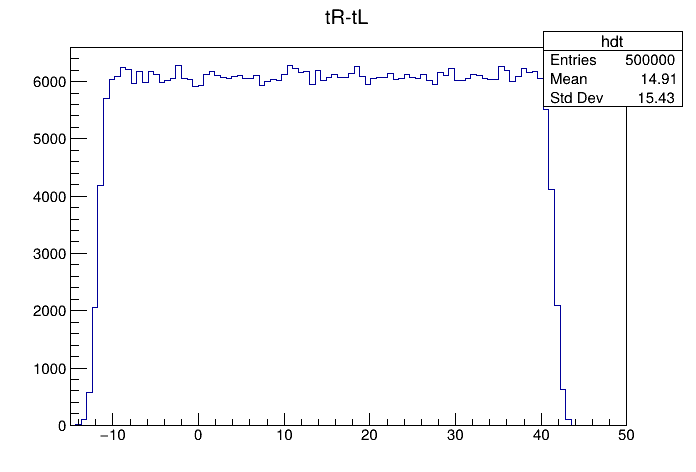

In [16]:
tree->Draw("tR-tL>>hdt(100,-15,50)");
c1->Draw();


<h4 id="4.4%EF%BC%9ATOF">4.4：TOF</h4><ul>
<li>观察以下两图有什么不同，分析其原因</li>
</ul>


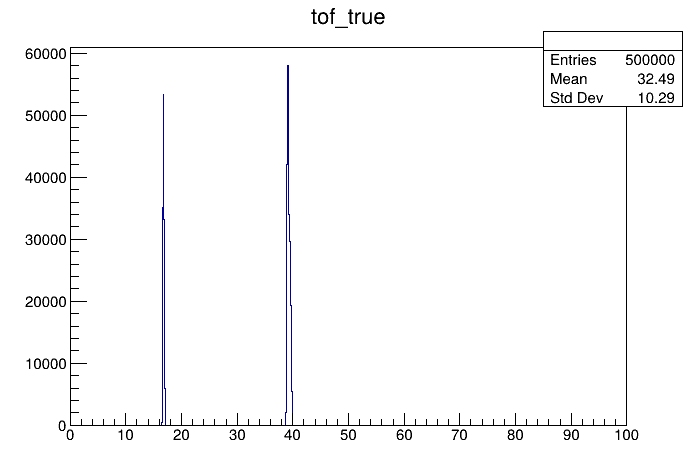

In [18]:
tree->Draw("tof_true>>(1000,0,100)","");//实际飞行时间
c1->Draw();

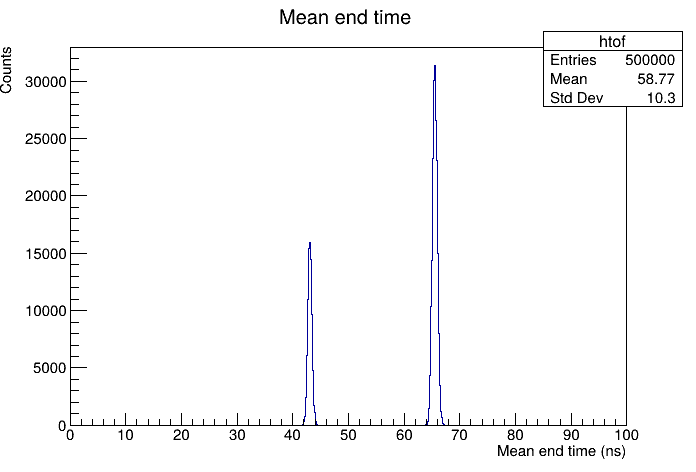

In [19]:
TH1D *hh = (TH1D*) ipf->Get("htof"); //在代码中得到文件内数据指针的方法，在ROOT环境下课直接用 htof->Draw()
hh->Draw();//画图
c1->Draw();


<h4 id="4.5-%E9%A3%9E%E8%A1%8C%E6%97%B6%E9%97%B4%E4%B8%8E%E4%BD%8D%E7%BD%AE%E7%9A%84%E4%BA%8C%E7%BB%B4%E5%85%B3%E8%81%94">4.5 飞行时间与位置的二维关联</h4><ul>
<li>右图：飞行距离修正，将TOF归一到 1m 的飞行距离；此时中子TOF与中子能量En存在一一对应关系，与入射位置无关。</li>
</ul>


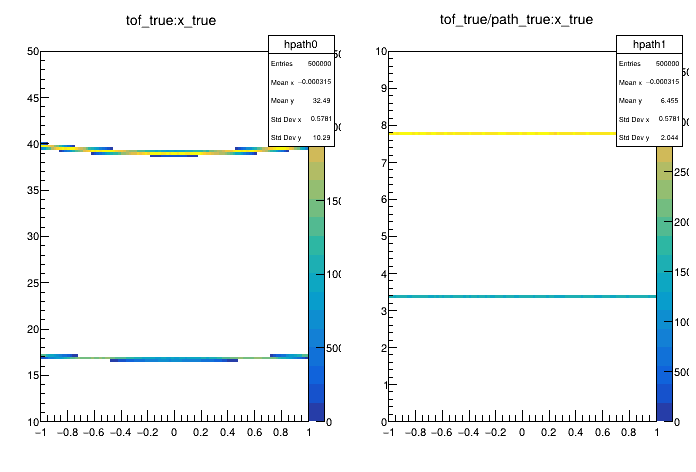

In [21]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1); tree->Draw("tof_true:x_true>>hpath0(100,-1,1,150,10,50)","","colz");
c1->cd(2); tree->Draw("tof_true/path_true:x_true>>hpath1(100,-1,1,150,0,10)","","colz");
c1->Draw();


<h4 id="4.6-%E4%BD%8D%E7%BD%AE">4.6 位置</h4><p>$$ x_{t} = \frac{v_{sc}}{2} (t_L - t_R - (t_{0L}-t_{0R}))$$
$$ x_q = \frac{\lambda}{2}\ln \frac{A_R g_L}{A_L g_R} $$</p>


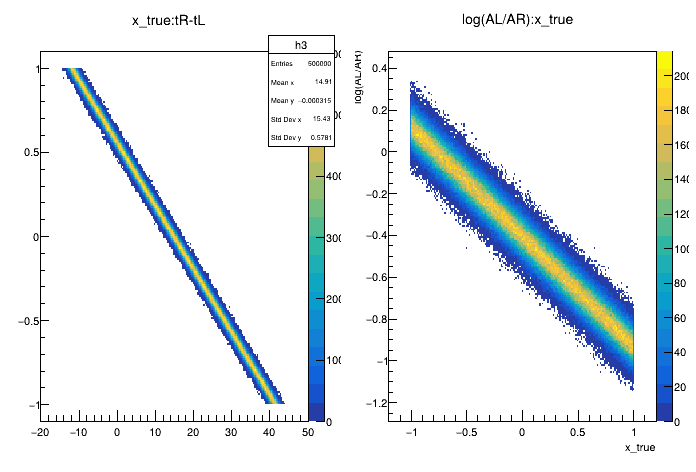

In [23]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("x_true:tR-tL >> h3(200, -20, 50, 200, -1.1, 1.1)", "", "colz");
c1->cd(2);
tree->Draw("log(AL/AR):x_true","","colz");
c1->Draw();


<h3 id="5.-%E4%BD%9C%E4%B8%9A">5. 作业</h3><p><strong>修改并完善代码</strong></p>
<p>目前的演示代码对物理过程进行了简化（例如假设中子能量单一、能量沉积固定等）。</p>
<p>根据下列要求，修改代码：</p>
<ol>
<li><p><strong>中子入射能量分布 ($E_n$)</strong>：</p>
<ul>
<li>中子源产生的能量并非单一值, 中子能量围绕中心值 <code>En0</code> 的高斯展宽（<code>EnFWHM</code>）。</li>
</ul>
</li>
<li><p><strong>中子能量沉积</strong>：</p>
<ul>
<li>模拟代码中 $A = A_{qe} * E_{dep}$。 根据讲义，在代码中加入探测器能量响应，即： $E_n\to E_p \to E_{ee}$， $Q = A_{qe} * E_{ee}$。</li>
</ul>
</li>
<li><p><strong>Time-walk</strong>：</p>
<ul>
<li>新增 tL_true, tR_true 两个Branch, 这两个变量分别等于模拟代码中的tL和tR。</li>
<li>变量 tL 和 tR: 在tL_true, tR_true 变量上，加入时间分辨随幅度变化的项以及Time-Walk 项。</li>
</ul>
</li>
<li><p><strong>电子学阈值与触发逻辑 (Trigger)</strong>：</p>
<ul>
<li>实验中存在电子学阈值（Threshold）。只有当探测器两端信号幅度（$A_L$ 和 $A_R$）<strong>各自</strong>都超过设定阈值时，该事件才会被记录。对应实验中的符合触发逻辑（Coincidence Trigger）。</li>
</ul>
</li>
</ol>
<p>程序给出不含测量涨落的 <code>tL_true/tR_true</code>；最终时间在加入 walk 后只展宽一次。保存 <code>depth_true/path_true</code> 用于与重建比较。分析未知数据时不使用这些真值。</p>


<h3 id="6.-%E8%80%83%E8%99%91%E4%BD%9C%E4%B8%9A%E4%B8%AD%E4%BF%AE%E6%AD%A3%E5%90%8E%E7%9A%84%E7%BB%93%E6%9E%9C">6. 考虑作业中修正后的结果</h3>


In [ ]:
.L create_tree_hw.cc

In [27]:
create_tree_hw();

Starting Simulation...

Processing: 0% completed...
Processing: 5% completed...
Processing: 10% completed...
Processing: 15% completed...
Processing: 20% completed...
Processing: 25% completed...
Processing: 30% completed...
Processing: 35% completed...
Processing: 40% completed...
Processing: 45% completed...
Processing: 50% completed...
Processing: 55% completed...
Processing: 60% completed...
Processing: 65% completed...
Processing: 70% completed...
Processing: 75% completed...
Processing: 80% completed...
Processing: 85% completed...
Processing: 90% completed...
Processing: 95% completed...
Processing: 100% completed!
Data saved to tree_hw_demo.root

In [ ]:
TFile *fHW = new TFile("tree_hw_demo.root");
TTree *tree = (TTree*)fHW->Get("tree");


<h4 id="6.1-Timewalk">6.1 Timewalk</h4><ul>
<li>timewalk导致时间谱产生严重的畸变，下一步必须对其进行修正。</li>
</ul>


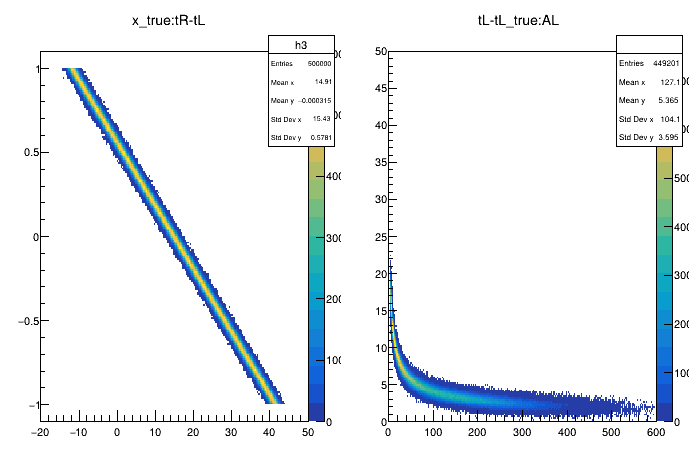

In [30]:
tree->Draw("tL-tL_true:AL>>(400,0,600,200,0,50)","","colz");
c1->Draw();


<h3 id="gamma%E4%BA%8B%E4%BB%B6%E9%80%89%E6%8B%A9">gamma事件选择</h3><ul>
<li>Gamma以光速飞行，其飞行时间最短，因此对应图中下方那条高度集中且平滑的窄带。在进行 Time-Walk 校准前，可以通过设置Graphical Cut，提取这Gamma 事件（见文档附录）。</li>
<li>下列代码保存到draw_gamma_cut.cc</li>
</ul>


In [ ]:
void draw_gamma_cut() {
   TCutG *cutg = new TCutG("cut_gamma",15);
   cutg->SetVarX("tL+tR");
   cutg->SetVarY("sqrt(AL*AR)");
   cutg->SetTitle("Graph");
   cutg->SetFillStyle(1000);
   cutg->SetPoint(0,86.7586,588.026);
   cutg->SetPoint(1,87.9764,331.974);
   cutg->SetPoint(2,89.803,105.395);
   cutg->SetPoint(3,96.5007,7.76315);
   cutg->SetPoint(4,118.116,-12.5);
   cutg->SetPoint(5,131.816,-3.28948);
   cutg->SetPoint(6,128.771,15.1316);
   cutg->SetPoint(7,113.549,28.0263);
   cutg->SetPoint(8,101.981,55.6579);
   cutg->SetPoint(9,96.1963,156.974);
   cutg->SetPoint(10,94.6741,304.342);
   cutg->SetPoint(11,94.0652,503.289);
   cutg->SetPoint(12,92.8474,591.711);
   cutg->SetPoint(13,85.8453,586.184);
   cutg->SetPoint(14,86.7586,588.026);
        
    // 注意：在分析代码中调用时，通常不需要它自动 Draw()
    cutg->Draw("L"); 
}

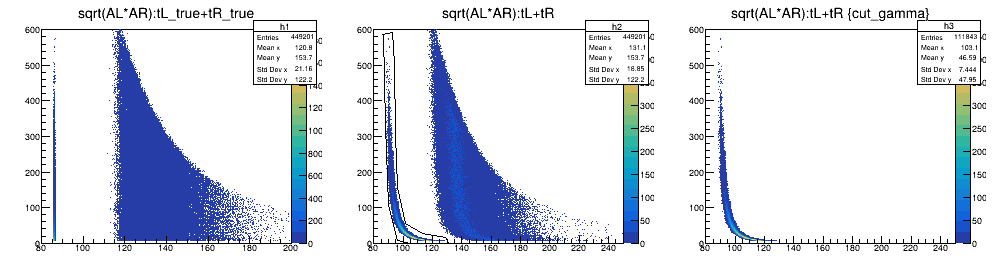

In [33]:
TCanvas *c2 = new TCanvas("tof-q","tof-q",1000,300);
c2->Divide(3,1);
c2->cd(1);
tree->Draw("sqrt(AL*AR):tL_true+tR_true>>h1(400,80,200,500,0,600)","","colz");
c2->cd(2);
tree->Draw("sqrt(AL*AR):tL+tR>>h2(400,80,250,500,0,600)","","colz");
draw_gamma_cut();
c2->cd(3);
tree->Draw("sqrt(AL*AR):tL+tR>>h3(400,80,250,500,0,600)","cut_gamma","colz");
c2->Draw();


<h3 id="%E9%99%84%E5%BD%95%EF%BC%9ACERN-ROOT-Graphic-Cut-(TCutG)-%E6%8C%87%E5%8D%97">附录：CERN ROOT Graphic Cut (TCutG) 指南</h3><h4 id="1.-%E5%BB%BA%E7%AB%8B%E4%B8%8A%E4%B8%8B%E6%96%87%EF%BC%9A%E7%BB%98%E5%88%B6%E6%95%A3%E7%82%B9%E5%9B%BE">1. 建立上下文：绘制散点图</h4><p>所有的图形化裁剪都始于对数据的可视化。</p>
<div class="highlight"><pre><span></span><span class="c1">// 在终端执行，假设 x 为横坐标变量，y 为纵坐标变量</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Draw</span><span class="p">(</span><span class="s">"y:x"</span><span class="p">,</span><span class="w"> </span><span class="s">""</span><span class="p">,</span><span class="w"> </span><span class="s">"colz"</span><span class="p">);</span><span class="w"> </span>
</pre></div>
<p><em>注意：在 <code>Draw</code> 命令中，顺序是 <strong>"纵轴:横轴"</strong>。</em></p>
<h4 id="2.-%E4%BA%A4%E4%BA%92%E5%BC%8F%E5%88%9B%E5%BB%BA%E4%B8%8E%E9%87%8D%E5%91%BD%E5%90%8D">2. 交互式创建与重命名</h4><ol>
<li><strong>激活工具</strong>：在 Canvas 菜单栏点击 <code>View -&gt; Toolbar</code>。点击图标中的 <strong>"CutG"</strong>（✂️）。</li>
<li><strong>绘制区域</strong>：在图中点击若干个点围成感兴趣的区域，<strong>双击</strong>最后一个点闭合。此时，该对象默认名为 <code>CUTG</code>。</li>
<li><strong>修改名称</strong>：<ul>
<li>将鼠标悬停在 Cut 边缘，<strong>右键</strong>点击 -&gt; <code>SetName</code>。</li>
<li>输入新名称，例如 <code>mycut</code>。这一步至关重要，因为后续调用都依赖此名称。</li>
</ul>
</li>
</ol>
<h4 id="3.-%E4%BF%9D%E5%AD%98%E4%B8%8E%E5%A4%8D%E7%94%A8-(.C-%E8%84%9A%E6%9C%AC)">3. 保存与复用 (.C 脚本)</h4><p>将你画好的形状保存下来，以便在以后的脚本或实验中使用：</p>
<ul>
<li><p><strong>操作</strong>：右键点击 Cut 边缘 -&gt; <code>SaveAs</code> -&gt; <code>mycut.C</code>。</p>
</li>
<li><p><strong>加载</strong>：在新的 ROOT 进程中，通过以下命令找回该 Cut：</p>
<div class="highlight"><pre><span></span><span class="n">root</span><span class="w"> </span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="p">.</span><span class="n">x</span><span class="w"> </span><span class="n">mycut</span><span class="p">.</span><span class="n">C</span><span class="p">;</span><span class="w"> </span><span class="c1">// 执行后，名为 "mycut" 的对象已加载至内存</span>
</pre></div>
</li>
</ul>
<h4 id="4.-%E5%9C%A8-ROOT-%E7%BB%88%E7%AB%AF%E7%9B%B4%E6%8E%A5%E8%B0%83%E7%94%A8">4. 在 ROOT 终端直接调用</h4><p>加载 <code>mycut</code> 后，它可以直接作为 <code>TTree::Draw</code> 的过滤条件，并支持与普通字符串条件混用。</p>
<ul>
<li><p><strong>基本应用</strong>：</p>
<div class="highlight"><pre><span></span><span class="n">tree</span><span class="o">-&gt;</span><span class="n">Draw</span><span class="p">(</span><span class="s">"y:x"</span><span class="p">,</span><span class="w"> </span><span class="s">"mycut"</span><span class="p">);</span><span class="w"> </span><span class="c1">// 仅显示 mycut 区域内的数据</span>
</pre></div>
</li>
<li><p><strong>条件混用</strong>：</p>
<div class="highlight"><pre><span></span><span class="c1">// 逻辑组合：在 mycut 区域内，且满足 x &gt; 100 且 y &gt; 50</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Draw</span><span class="p">(</span><span class="s">"y:x"</span><span class="p">,</span><span class="w"> </span><span class="s">"mycut &amp;&amp; x &gt; 100 &amp;&amp; y &gt; 50"</span><span class="p">);</span>
</pre></div>
</li>
</ul>
<h4 id="5.-%E5%9C%A8%E5%BE%AA%E7%8E%AF%E4%BB%A3%E7%A0%81%E4%B8%AD%E5%BC%95%E7%94%A8-(C++-Loop)">5. 在循环代码中引用 (C++ Loop)</h4><p>如果你在编写 <code>for</code> 循环手动处理每个 Event，需要使用 <code>IsInside</code> 方法。</p>
<p><strong>⚠️ 核心要点：参数顺序必须与定义一致</strong>
在第一步 <code>tree-&gt;Draw("y:x")</code> 中，你的横轴是 <code>x</code>，纵轴是 <code>y</code>。因此在调用 <code>IsInside</code> 时，<strong>必须严格保持 (横轴变量, 纵轴变量)</strong> 的顺序。</p>
<div class="highlight"><pre><span></span><span class="c1">// 1. 加载 Cut 对象</span>
<span class="n">gROOT</span><span class="o">-&gt;</span><span class="n">ProcessLine</span><span class="p">(</span><span class="s">".x mycut.C"</span><span class="p">);</span>
<span class="n">TCutG</span><span class="w"> </span><span class="o">*</span><span class="n">mycut</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="p">(</span><span class="n">TCutG</span><span class="o">*</span><span class="p">)</span><span class="n">gROOT</span><span class="o">-&gt;</span><span class="n">FindObject</span><span class="p">(</span><span class="s">"mycut"</span><span class="p">);</span>

<span class="c1">// 2. 进入事件循环</span>
<span class="k">for</span><span class="w"> </span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="n">tree</span><span class="o">-&gt;</span><span class="n">GetEntries</span><span class="p">();</span><span class="w"> </span><span class="o">++</span><span class="n">i</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="n">tree</span><span class="o">-&gt;</span><span class="n">GetEntry</span><span class="p">(</span><span class="n">i</span><span class="p">);</span>
<span class="w">    </span>
<span class="w">    </span><span class="c1">// 判定：第一个参数是绘图时的横轴(x)，第二个参数是纵轴(y)</span>
<span class="w">    </span><span class="c1">// 变量顺序如果写反为 (valY, valX)，判定结果将完全错误</span>
<span class="w">    </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">mycut</span><span class="o">-&gt;</span><span class="n">IsInside</span><span class="p">(</span><span class="n">valX</span><span class="p">,</span><span class="w"> </span><span class="n">valY</span><span class="p">))</span><span class="w"> </span><span class="p">{</span><span class="w"> </span>
<span class="w">        </span><span class="c1">// 逻辑处理...</span>
<span class="w">    </span><span class="p">}</span>
<span class="p">}</span>
</pre></div>
<hr/>
